# 2_03 — The panel-level relation on the expanded source, against the narrow one

## Scope

`2_01_relation_baseline.ipynb` establishes the panel-level relation on
the serum-scope extraction: 40 EC numbers, reporter substrates only, a window
of three subsites in the median case.

Three things changed since:

* the EC scope widened from the serum panel to every peptidase BRENDA holds
  human kinetics for (`0_10_brenda_extension.ipynb`);
* internally quenched substrates became usable through the latent-bond
  treatment (`2_05_site_recovery_baseline.ipynb`), which is the only way the
  prime side of a matrix is reached at all;
* the kinetic label gained the ratios recovered from matched $k_{cat}$ and
  $K_M$.

This notebook repeats the `2_01` analysis on the expanded set and compares the
two directly. `2_01` is left untouched as the narrow-scope baseline, so the
difference between them is readable rather than overwritten.

## What a comparison of the two can and cannot show

The two analyses do not share a null. The expanded set uses a maximum over
candidate bonds for quenched substrates, which is mechanically larger than a
fixed-bond score, and it covers different proteases. A larger correlation here
is therefore **not** evidence that the expansion improved anything by itself.

What is comparable is the per-protease correlation on the proteases present in
both, where the same enzyme is scored with the same matrix against the same
kind of label. That comparison is the subject of the second half.

## Execution contract

**Inputs:** `results/2_06_substrate_table.csv`; `results/2_01_merops_vs_kinetics_per_protease.csv`; `results/0_10_brenda_extension.csv`; `data/merops/34_homo_sapiens/codes.json`.

**Outputs:** `results/2_03_scope_comparison.csv`; `results/2_03_relation_extended.csv`.

**Depends on:** `2_06` (a later notebook), `2_01`, `0_10`.

**Boundary:** A larger panel with correlated mapped rows does not prove better generalisation.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import load_panel_metadata

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
MIN_WINDOWS = 3
MIN_INTERPRETABLE_WINDOWS = 6
N_BOOTSTRAP = 2000
SEED = 20260920

In [3]:
names = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata(list(range(36)), merops_root=common.MEROPS_ROOT)
}

expanded = pd.read_csv(common.RESULTS_ROOT / "2_06_substrate_table.csv")
narrow_results = pd.read_csv(common.RESULTS_ROOT / "2_01_merops_vs_kinetics_per_protease.csv")
integration = pd.read_csv(common.RESULTS_ROOT / "0_10_brenda_extension.csv")

print(f"expanded substrate table: {len(expanded)} pairs, "
      f"{expanded['merops_code'].nunique()} proteases")
print(expanded["window_convention"].value_counts().to_string())
print()
print(f"narrow-scope result table ({len(narrow_results)} proteases) loaded for comparison")

expanded substrate table: 810 pairs, 84 proteases
window_convention
quenched    434
reporter    376

narrow-scope result table (12 proteases) loaded for comparison


## Carrying the EC ambiguity forward

`0_10` reports that 24% of the extracted entries are attached to more than one
MEROPS code, because one EC number can describe an activity shared by several
paralogues. Only one of them catalysed the measurement.

Such a protease is not excluded, because excluding it would also remove the one
that really did catalyse it. It is flagged, so that a correlation resting on
shared measurements is recognisable.

In [4]:
ambiguity = dict(
    zip(integration["merops_code"], integration.get("shares_measurements_with_n_codes", 1))
)
expanded["shares_measurements_with_n_codes"] = (
    expanded["merops_code"].map(ambiguity).fillna(1).astype(int)
)
shared_flag = expanded.groupby("merops_code")["shares_measurements_with_n_codes"].max()
print(f"proteases whose measurements are theirs alone: {int((shared_flag == 1).sum())}")
print(f"proteases sharing measurements with others:    {int((shared_flag > 1).sum())}")

proteases whose measurements are theirs alone: 57
proteases sharing measurements with others:    27


## Per-protease relation on the expanded set

The statistic is the same as in `2_01`: a Spearman correlation between the
window score and log10 $k_{cat}/K_M$, computed within each protease, with a
bootstrap interval over substrates.

In [5]:
generator = np.random.default_rng(SEED)
records = []
for code, group in expanded.groupby("merops_code"):
    group = group.drop_duplicates(subset="substrate_sequence")
    if len(group) < MIN_WINDOWS:
        continue
    scores = group["merops_score"].to_numpy()
    measured = group["log10_kcat_over_km"].to_numpy()
    observed_rho = spearmanr(scores, measured).statistic

    bootstrap = []
    for _ in range(N_BOOTSTRAP):
        index = generator.integers(0, len(group), len(group))
        if len(np.unique(scores[index])) < 2 or len(np.unique(measured[index])) < 2:
            continue
        bootstrap.append(spearmanr(scores[index], measured[index]).statistic)
    bootstrap = np.array([value for value in bootstrap if np.isfinite(value)])

    records.append(
        {
            "merops_code": code,
            "name": names.get(code, ""),
            "merops_cleavages": int(group["merops_cleavages"].iloc[0]),
            "n_windows": len(group),
            "n_quenched": int((group["window_convention"] == "quenched").sum()),
            "median_subsites": float(group["n_observed_subsites"].median()),
            "spearman_rho": float(observed_rho) if np.isfinite(observed_rho) else np.nan,
            "ci_low": float(np.percentile(bootstrap, 2.5)) if len(bootstrap) else np.nan,
            "ci_high": float(np.percentile(bootstrap, 97.5)) if len(bootstrap) else np.nan,
            "shares_measurements_with_n_codes": int(group["shares_measurements_with_n_codes"].iloc[0]),
        }
    )

per_protease = pd.DataFrame(records).sort_values("n_windows", ascending=False).reset_index(drop=True)
per_protease["interpretable"] = per_protease["n_windows"] >= MIN_INTERPRETABLE_WINDOWS
interpretable = per_protease[per_protease["interpretable"]]

print(f"proteases with at least {MIN_WINDOWS} substrates: {len(per_protease)}")
print(f"  of those with at least {MIN_INTERPRETABLE_WINDOWS}: {len(interpretable)}")
print(f"  with a positive lower confidence bound: {int((interpretable['ci_low'] > 0).sum())}")
print(f"  with a negative point estimate:         {int((interpretable['spearman_rho'] < 0).sum())}")
print()
print(
    interpretable.head(18)[
        ["merops_code", "name", "n_windows", "n_quenched", "median_subsites",
         "spearman_rho", "ci_low", "ci_high", "shares_measurements_with_n_codes"]
    ].round(3).to_string(index=False)
)

proteases with at least 3 substrates: 57
  of those with at least 6: 36
  with a positive lower confidence bound: 9
  with a negative point estimate:         6

merops_code                                           name  n_windows  n_quenched  median_subsites  spearman_rho  ci_low  ci_high  shares_measurements_with_n_codes
    S01.161                 kallikrein-related peptidase 2         67          57              5.0        -0.176  -0.461    0.117                                 2
    S01.160                                   kallikrein 1         67          57              7.0         0.519   0.296    0.702                                 2
    C01.032                                    cathepsin L         67          64              7.0         0.543   0.343    0.698                                 2
    A01.009                                    cathepsin D         55          55              8.0         0.193  -0.088    0.425                                 1
    S01.140        

## Pooled relation

Score and measurement are centred within protease, as in `2_01`, and the null
comes from shuffling the measurements inside each protease.

In [6]:
pooled = expanded.drop_duplicates(subset=["merops_code", "substrate_sequence"]).copy()
pooled = pooled[pooled["merops_code"].isin(per_protease["merops_code"])]
pooled["score_centred"] = pooled.groupby("merops_code")["merops_score"].transform(
    lambda values: values - values.mean()
)
pooled["kinetics_centred"] = pooled.groupby("merops_code")["log10_kcat_over_km"].transform(
    lambda values: values - values.mean()
)
pooled_rho = spearmanr(pooled["score_centred"], pooled["kinetics_centred"]).statistic

permutation_generator = np.random.default_rng(SEED)
null_rho = []
for _ in range(N_BOOTSTRAP):
    shuffled = pooled.copy()
    shuffled["kinetics_centred"] = shuffled.groupby("merops_code")["kinetics_centred"].transform(
        lambda values: permutation_generator.permutation(values.to_numpy())
    )
    null_rho.append(spearmanr(shuffled["score_centred"], shuffled["kinetics_centred"]).statistic)
null_rho = np.array(null_rho)
empirical_p = float((np.abs(null_rho) >= abs(pooled_rho)).mean())

print(f"pooled observations: {len(pooled)} across {pooled['merops_code'].nunique()} proteases")
print(f"within-protease Spearman rho = {pooled_rho:.3f}")
print(f"permutation null: 95th percentile of |rho| = {np.percentile(np.abs(null_rho), 95):.3f}")
print(f"empirical two-sided p = {empirical_p:.4f} over {N_BOOTSTRAP} permutations")

pooled observations: 773 across 57 proteases
within-protease Spearman rho = 0.356
permutation null: 95th percentile of |rho| = 0.074
empirical two-sided p = 0.0000 over 2000 permutations


### The narrow-scope figures, for reference

From `2_01`, on the serum-scope reporter-only substrates.

In [7]:
narrow_pooled_rho = float(narrow_results["pooled_within_protease_rho"].iloc[0])
narrow_pooled_p = float(narrow_results["pooled_permutation_p"].iloc[0])
narrow_interpretable = narrow_results.query("n_windows >= @MIN_INTERPRETABLE_WINDOWS")

comparison = pd.DataFrame(
    [
        {"quantity": "proteases with >=3 substrates",
         "narrow_scope": len(narrow_results), "expanded_scope": len(per_protease)},
        {"quantity": f"proteases with >={MIN_INTERPRETABLE_WINDOWS} substrates",
         "narrow_scope": len(narrow_interpretable), "expanded_scope": len(interpretable)},
        {"quantity": "pooled observations",
         "narrow_scope": int(narrow_results["n_windows"].sum()), "expanded_scope": len(pooled)},
        {"quantity": "pooled within-protease rho",
         "narrow_scope": round(narrow_pooled_rho, 3), "expanded_scope": round(float(pooled_rho), 3)},
        {"quantity": "pooled permutation p",
         "narrow_scope": narrow_pooled_p, "expanded_scope": empirical_p},
        {"quantity": "median subsites populated",
         "narrow_scope": 3.0, "expanded_scope": float(expanded["n_observed_subsites"].median())},
    ]
)
print(comparison.to_string(index=False))

                     quantity  narrow_scope  expanded_scope
proteases with >=3 substrates        12.000          57.000
proteases with >=6 substrates         9.000          36.000
          pooled observations       113.000         773.000
   pooled within-protease rho         0.455           0.356
         pooled permutation p         0.000           0.000
    median subsites populated         3.000           5.000


## The same protease, scored under both scopes

This is the comparison that controls for everything except the substrate set:
the same enzyme, the same matrix, the same kind of label. A protease whose
correlation moves between the two is telling us that its narrow-scope value was
driven by the reporter substrates alone.

In [8]:
shared = narrow_results[["merops_code", "n_windows", "spearman_rho", "ci_low", "ci_high"]].merge(
    per_protease[["merops_code", "name", "n_windows", "n_quenched", "spearman_rho", "ci_low", "ci_high"]],
    on="merops_code",
    suffixes=("_narrow", "_expanded"),
)
shared["substrates_added"] = shared["n_windows_expanded"] - shared["n_windows_narrow"]
shared["rho_change"] = shared["spearman_rho_expanded"] - shared["spearman_rho_narrow"]
print(f"proteases present in both analyses: {len(shared)}")
print()
print(
    shared[
        ["merops_code", "name", "n_windows_narrow", "n_windows_expanded", "substrates_added",
         "n_quenched", "spearman_rho_narrow", "spearman_rho_expanded", "rho_change"]
    ].round(3).sort_values("substrates_added", ascending=False).to_string(index=False)
)
print()
print(f"median change in rho: {shared['rho_change'].median():+.3f}")
print(f"proteases whose rho rose: {int((shared['rho_change'] > 0).sum())} of {len(shared)}")

proteases present in both analyses: 12

merops_code                                name  n_windows_narrow  n_windows_expanded  substrates_added  n_quenched  spearman_rho_narrow  spearman_rho_expanded  rho_change
    S01.160                        kallikrein 1                10                  67                57          57                0.273                  0.519       0.246
    S01.161      kallikrein-related peptidase 2                10                  67                57          57               -0.515                 -0.176       0.339
    S01.140       chymase ({Homo sapiens}-type)                26                  38                12          12                0.769                  0.666      -0.103
    S01.134                        myeloblastin                12                  17                 5           5                0.552                  0.343      -0.209
    S01.010    granzyme B ({Homo sapiens}-type)                 4                   9               

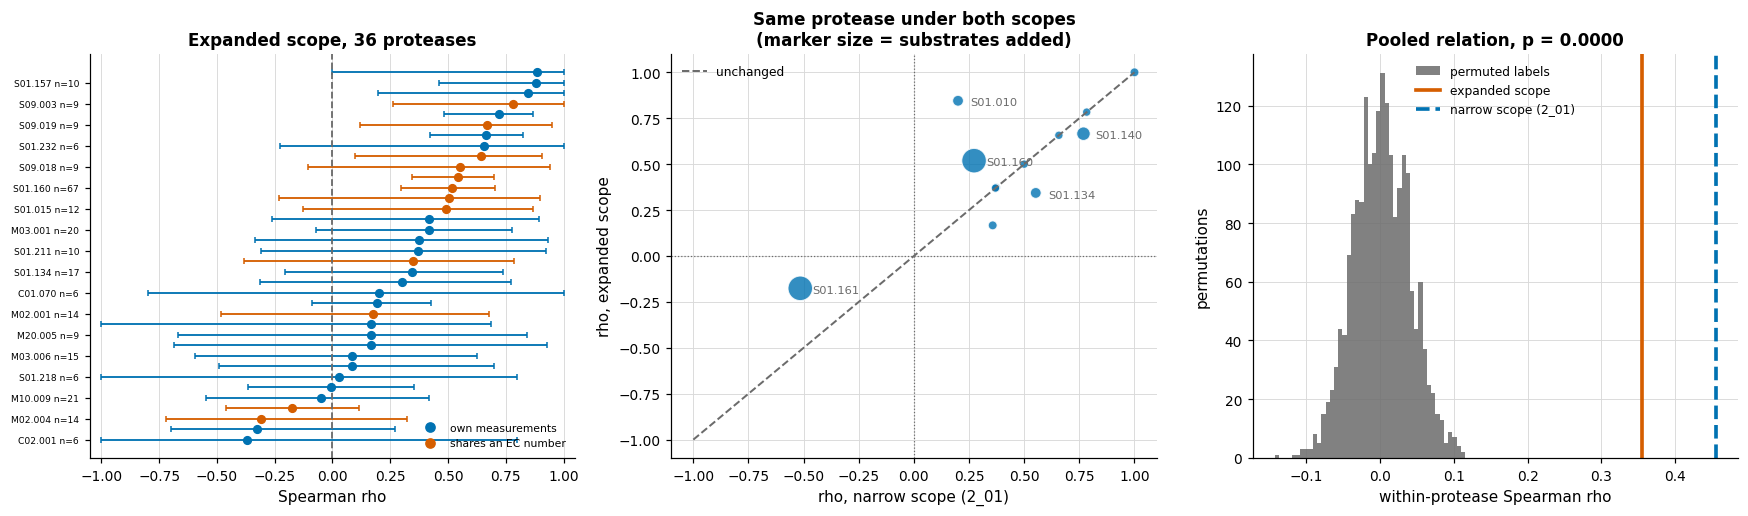

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.8))

ax = axes[0]
ordered = interpretable.sort_values("spearman_rho").reset_index(drop=True)
for position, row in ordered.iterrows():
    colour = (
        common.CATEGORICAL_COLORS[1]
        if row["shares_measurements_with_n_codes"] > 1
        else common.CATEGORICAL_COLORS[0]
    )
    ax.errorbar(
        row["spearman_rho"], position,
        xerr=[[row["spearman_rho"] - row["ci_low"]], [row["ci_high"] - row["spearman_rho"]]],
        fmt="o", color=colour, ecolor=colour, elinewidth=1.2, capsize=2, markersize=5,
    )
ax.axvline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.2)
ax.set_yticks(ordered.index[::2])
ax.set_yticklabels([f"{row.merops_code} n={row.n_windows}" for row in ordered.iloc[::2].itertuples()], fontsize=6)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Spearman rho")
ax.set_title(f"Expanded scope, {len(interpretable)} proteases")
ax.grid(axis="y", visible=False)
handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=common.CATEGORICAL_COLORS[0], label="own measurements"),
    plt.Line2D([], [], marker="o", linestyle="", color=common.CATEGORICAL_COLORS[1], label="shares an EC number"),
]
ax.legend(handles=handles, loc="lower right", fontsize=7)

ax = axes[1]
ax.scatter(
    shared["spearman_rho_narrow"], shared["spearman_rho_expanded"],
    s=np.clip(shared["substrates_added"] * 4 + 30, 30, 300),
    color=common.CATEGORICAL_COLORS[0], alpha=0.8, edgecolor="white", linewidth=0.7,
)
ax.plot([-1, 1], [-1, 1], color=common.NEUTRAL, linestyle="--", linewidth=1.3, label="unchanged")
for _, row in shared.nlargest(5, "substrates_added").iterrows():
    ax.annotate(
        row["merops_code"], (row["spearman_rho_narrow"], row["spearman_rho_expanded"]),
        textcoords="offset points", xytext=(8, -3), fontsize=7.5, color=common.NEUTRAL,
    )
ax.axhline(0, color=common.NEUTRAL, linewidth=0.8, linestyle=":")
ax.axvline(0, color=common.NEUTRAL, linewidth=0.8, linestyle=":")
ax.set_xlabel("rho, narrow scope (2_01)")
ax.set_ylabel("rho, expanded scope")
ax.set_title("Same protease under both scopes\n(marker size = substrates added)")
ax.legend(fontsize=8)

ax = axes[2]
ax.hist(null_rho, bins=45, color=common.NEUTRAL, alpha=0.85, label="permuted labels")
ax.axvline(pooled_rho, color=common.CATEGORICAL_COLORS[1], linewidth=2.4, label="expanded scope")
ax.axvline(narrow_pooled_rho, color=common.CATEGORICAL_COLORS[0], linewidth=2.4,
           linestyle="--", label="narrow scope (2_01)")
ax.set_xlabel("within-protease Spearman rho")
ax.set_ylabel("permutations")
ax.set_title(f"Pooled relation, p = {empirical_p:.4f}")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Provenance**

The expanded score/label rows come from `results/2_06_substrate_table.csv`, produced in `2_06` from BRENDA 2026.1 all-peptidase extraction and MEROPS 2023. The narrow comparison is `results/2_01_merops_vs_kinetics_per_protease.csv`; `results/0_10_brenda_extension.csv` supplies EC-to-code sharing counts. Code cells 8–14 compute per-code and pooled within-code rank associations and pair codes present in both scopes. One row of `results/2_03_relation_extended.csv` is one MEROPS code, whereas the underlying substrate rows can share EC measurements. Kinetic labels are log10 kcat/Km in 1/(M·s), and a change in sample composition can change ρ without improving the score. Verify the paired code list and CI columns in `results/2_03_scope_comparison.csv`.

> **Caveat.** For a FRET/quenched substrate with no resolved cleavage bond, `0_15_analysis_datasets.ipynb` cell 6 selects the maximum MEROPS score over admissible bonds (`argmax`). This selected maximum is a model-derived statistic, not a measured cut site; it can rise with peptide length and a sharper matrix even without better prediction. Report MEROPS–kinetics associations separately for `reporter` (known bond) and `quenched` (selected bond) conventions. Rows sharing one BRENDA measurement across MEROPS codes are dependent (`shares_measurements_with_n_codes`), so nominal N and permutation significance may be optimistic.


## Result table

One row per protease with at least three substrates under the expanded scope,
with its narrow-scope value where one exists. The verdicts on held-out
substrates are decided in `2_02_holdout_baseline.ipynb`; nothing here is
a held-out test.

In [10]:
result = per_protease.merge(
    narrow_results[["merops_code", "n_windows", "spearman_rho"]].rename(
        columns={"n_windows": "n_windows_narrow", "spearman_rho": "spearman_rho_narrow"}
    ),
    on="merops_code",
    how="left",
)
result["pooled_within_protease_rho"] = pooled_rho
result["pooled_permutation_p"] = empirical_p
result["scope_comparison"] = np.where(
    result["spearman_rho_narrow"].notna(), "in_both_scopes", "expanded_scope_only"
)

common.save_result(comparison, "2_03_scope_comparison.csv")
destination = common.save_result(result, "2_03_relation_extended.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
print()
print(result["scope_comparison"].value_counts().to_string())
result.sort_values("n_windows", ascending=False).head(12)[
    ["merops_code", "name", "n_windows", "n_quenched", "spearman_rho", "spearman_rho_narrow", "scope_comparison"]
]

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_03_relation_extended.csv

scope_comparison
expanded_scope_only    45
in_both_scopes         12


,merops_code,name,n_windows,n_quenched,spearman_rho,spearman_rho_narrow,scope_comparison
0,S01.161,kallikrein-related peptidase 2,67,57,-0.176087,-0.515152,in_both_scopes
2,C01.032,cathepsin L,67,64,0.543310,NaN,expanded_scope_only
1,S01.160,kallikrein 1,67,57,0.518947,0.272727,in_both_scopes
3,A01.009,cathepsin D,55,55,0.192614,NaN,expanded_scope_only
4,S01.140,chymase ({Homo sapiens}-type),38,12,0.665864,0.768678,in_both_scopes
5,S08.071,furin,32,22,0.722523,NaN,expanded_scope_only
6,S01.300,kallikrein-related peptidase 7,29,21,-0.006404,NaN,expanded_scope_only
7,M10.009,matrix metallopeptidase-12,21,21,-0.048052,NaN,expanded_scope_only
8,M03.001,thimet oligopeptidase,20,20,0.418045,NaN,expanded_scope_only
9,S01.134,myeloblastin,17,5,0.343348,0.552448,in_both_scopes
